In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

from hmmlearn.hmm import GaussianHMM

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(
    r"C:/A-CMSI research/Data/HMM data/HMM_Input_features.csv"
)

df.head()

,Date,SPY_Return,SPY_V,RollingVol21,RollingSkew21,Drawdown,VolOfVol,VIX,C_t
0,2016-01-04,-0.014078,0.625878,0.011695,0.098234,-0.043852,0.000981,20.700001,0.828265
1,2016-01-05,0.001690,1.047069,0.011344,-0.024522,-0.042234,0.000862,19.340000,0.801967
2,2016-01-06,-0.012695,0.768872,0.010648,-0.000368,-0.054316,0.000815,20.590000,0.758904
3,2016-01-07,-0.024284,1.088437,0.011669,-0.115220,-0.077004,0.000800,24.990000,0.811198
4,2016-01-08,-0.011037,2.182559,0.011773,-0.072950,-0.087135,0.000784,27.010000,0.791320


In [5]:
df.info()

df.describe()

df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2513 entries, 0 to 2512
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           2513 non-null   str    
 1   SPY_Return     2513 non-null   float64
 2   SPY_V          2513 non-null   float64
 3   RollingVol21   2513 non-null   float64
 4   RollingSkew21  2513 non-null   float64
 5   Drawdown       2513 non-null   float64
 6   VolOfVol       2513 non-null   float64
 7   VIX            2513 non-null   float64
 8   C_t            2513 non-null   float64
dtypes: float64(8), str(1)
memory usage: 201.4 KB


Date             0
SPY_Return       0
SPY_V            0
RollingVol21     0
RollingSkew21    0
Drawdown         0
VolOfVol         0
VIX              0
C_t              0
dtype: int64

In [6]:
features = [
    "SPY_Return",
    "SPY_V",
    "RollingVol21",
    "RollingSkew21",
    "Drawdown",
    "VolOfVol",
    "VIX",
    "C_t"
]

X = df[features]

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
X_scaled.mean(axis=0)

X_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1.])

In [11]:
best_model = None
best_score = -np.inf

for seed in range(30):

    model = GaussianHMM(
        n_components=3,
        covariance_type="full",
        n_iter=200,
        random_state=seed
    )

    model.fit(X_scaled)

    score = model.score(X_scaled)

    if score > best_score:

        best_score = score
        best_model = model

print(best_score)

-15145.50063017959


In [12]:
hidden_states = best_model.predict(X_scaled)

df["State"] = hidden_states

In [13]:
state_prob = best_model.predict_proba(X_scaled)

In [14]:
df.groupby("State")[[
    "SPY_Return",
    "SPY_V",
    "RollingVol21",
    "Drawdown",
    "VIX"
]].mean()

,SPY_Return,SPY_V,RollingVol21,Drawdown,VIX
State,,,,,
0,0.000257,0.358597,0.011116,-0.086938,20.122937
1,0.001037,-0.635040,0.005988,-0.005574,14.776909
2,-0.000399,0.736438,0.017103,-0.072047,27.201192


In [15]:
state_names = {
    0: "Neutral",
    1: "Bull",
    2: "Panic"
}

df["Regime"] = df["State"].map(state_names)

In [16]:
df["P_t"] = state_prob[:, 2]

In [17]:
print(best_model.transmat_)

[[0.97967501 0.01483166 0.00549333]
 [0.00697428 0.98300341 0.01002231]
 [0.02292675 0.0244076  0.95266566]]


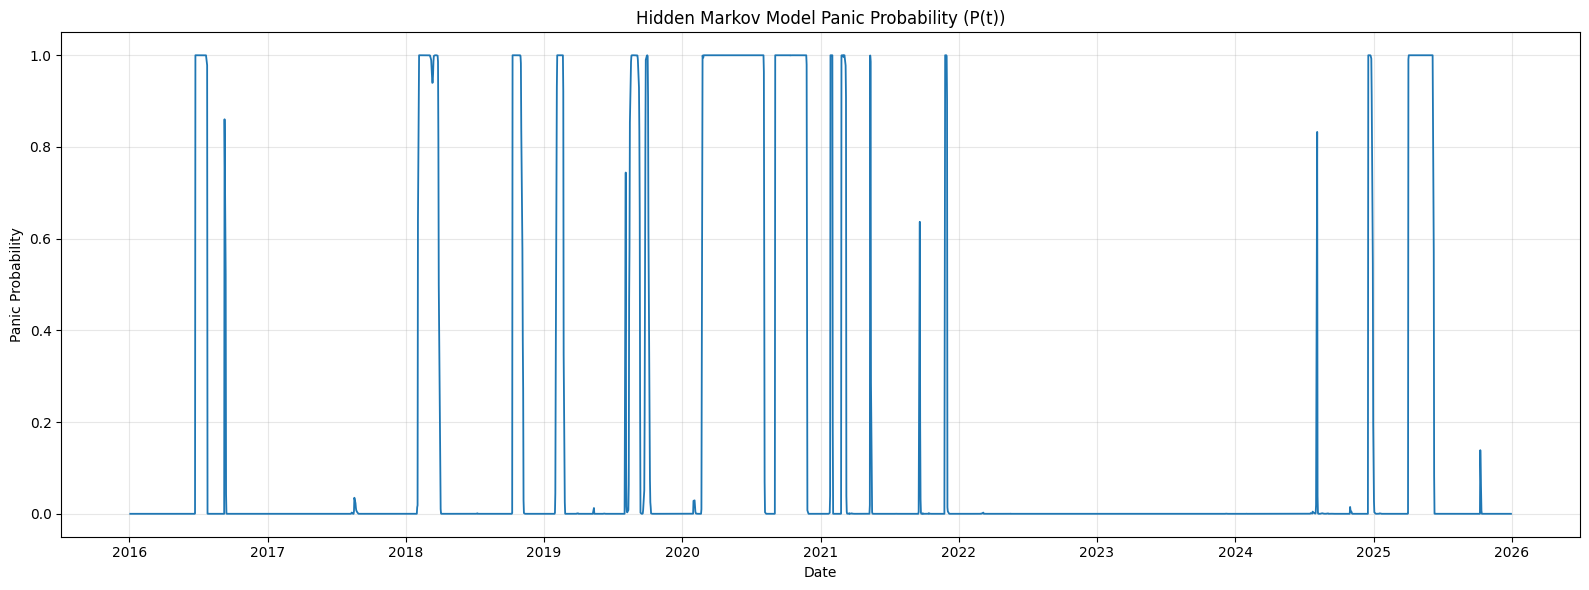

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.plot(
    pd.to_datetime(df["Date"]),
    df["P_t"],
    linewidth=1.3
)

plt.title("Hidden Markov Model Panic Probability (P(t))")
plt.xlabel("Date")
plt.ylabel("Panic Probability")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

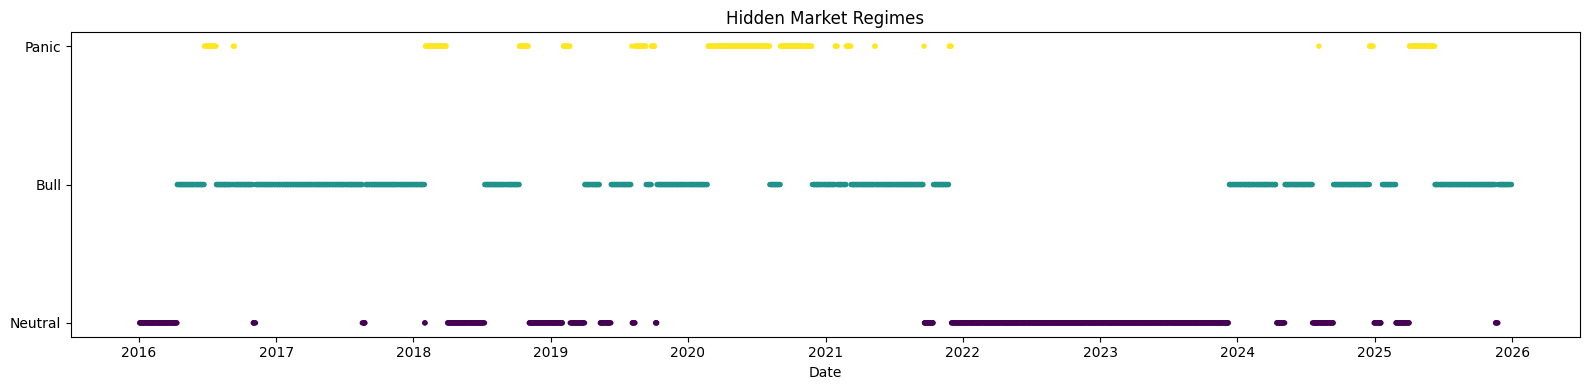

In [20]:
plt.figure(figsize=(16,4))

plt.scatter(
    pd.to_datetime(df["Date"]),
    df["State"],
    c=df["State"],
    cmap="viridis",
    s=8
)

plt.yticks([0,1,2],["Neutral","Bull","Panic"])

plt.title("Hidden Market Regimes")

plt.xlabel("Date")

plt.tight_layout()
plt.show()

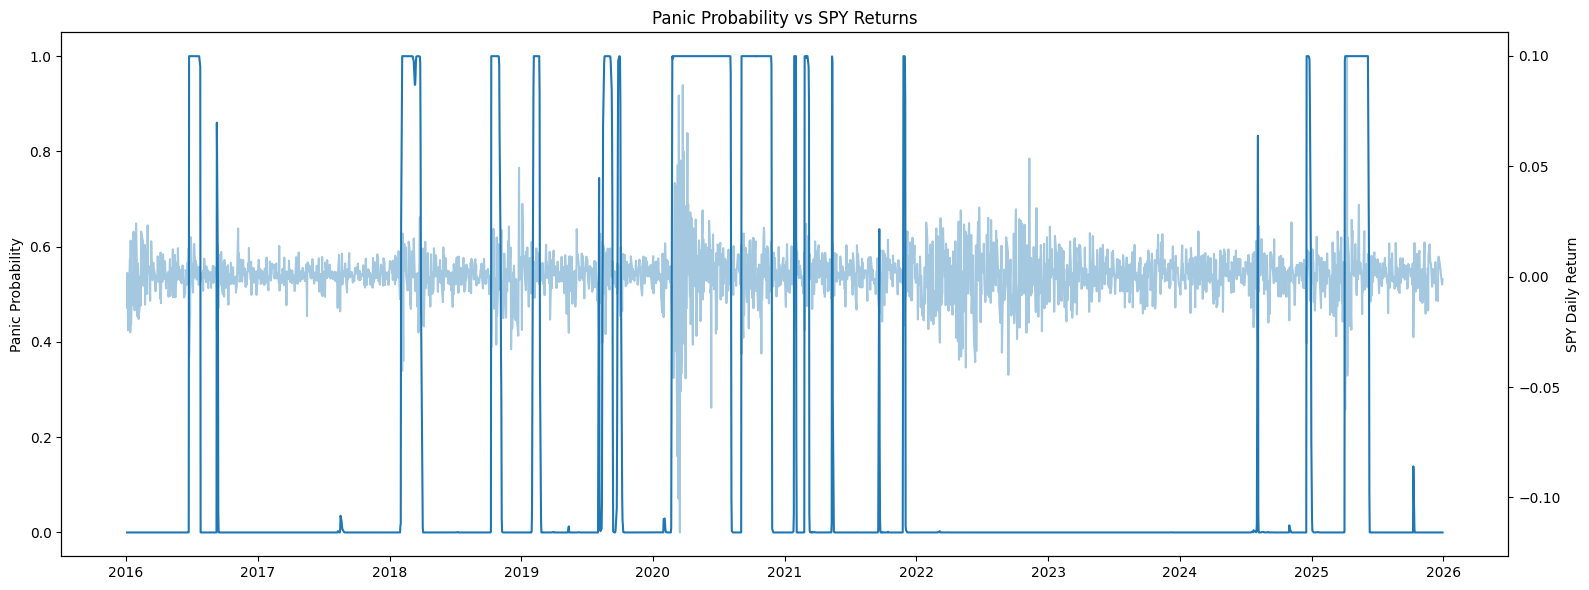

In [21]:
fig, ax1 = plt.subplots(figsize=(16,6))

ax1.plot(
    pd.to_datetime(df["Date"]),
    df["P_t"],
    label="Panic Probability",
    linewidth=1.5
)

ax1.set_ylabel("Panic Probability")

ax2 = ax1.twinx()

ax2.plot(
    pd.to_datetime(df["Date"]),
    df["SPY_Return"],
    alpha=0.4
)

ax2.set_ylabel("SPY Daily Return")

plt.title("Panic Probability vs SPY Returns")

plt.tight_layout()
plt.show()

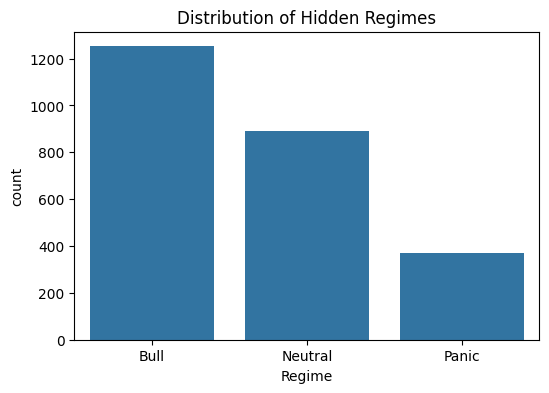

In [22]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Regime",
    order=["Bull","Neutral","Panic"]
)

plt.title("Distribution of Hidden Regimes")

plt.show()

In [23]:
print(best_model.means_)

[[-0.03089213  0.41084104  0.25823227  0.19310462 -0.74302499 -0.14046219
   0.22317924  0.44291125]
 [ 0.04440285 -0.51598891 -0.53423234  0.034138    0.67357353 -0.32708945
  -0.50842077 -0.54676836]
 [-0.07584784  0.75560323  1.18777269 -0.58438597 -0.48490167  1.45152605
   1.18515374  0.78232888]]


In [24]:
import pandas as pd

means = pd.DataFrame(
    scaler.inverse_transform(best_model.means_),
    columns=features
)

print(means)

   SPY_Return     SPY_V  RollingVol21  RollingSkew21  Drawdown  VolOfVol  \
0    0.000198  0.361259      0.011109      -0.044631 -0.086854  0.001242   
1    0.001054 -0.636361      0.005988      -0.146876 -0.005562  0.000907   
2   -0.000313  0.732354      0.017116      -0.544702 -0.072042  0.004100   

         VIX       C_t  
0  20.134950  0.736924  
1  14.771652  0.548981  
2  27.187104  0.801381  


In [25]:
print(best_model.covars_)

[[[ 1.05944756e+00  1.88848575e-02  5.26961190e-03  7.03521668e-02
    1.10114136e-01  1.02584270e-02 -1.40881608e-01 -2.45338848e-02]
  [ 1.88848575e-02  1.22418224e+00  3.00092883e-01 -2.60603111e-01
   -7.74898436e-02  1.60697402e-01  4.64950648e-01  2.47978560e-01]
  [ 5.26961190e-03  3.00092883e-01  3.71126525e-01  6.55486291e-02
   -3.99888688e-01  8.86779868e-02  3.14730346e-01  3.21220174e-01]
  [ 7.03521668e-02 -2.60603111e-01  6.55486291e-02  5.47415355e-01
   -1.68536528e-01 -7.53600576e-05 -6.01854492e-04  5.22735435e-02]
  [ 1.10114136e-01 -7.74898436e-02 -3.99888688e-01 -1.68536528e-01
    1.02148690e+00 -2.39268535e-02 -4.99098731e-01 -3.56517629e-01]
  [ 1.02584270e-02  1.60697402e-01  8.86779868e-02 -7.53600576e-05
   -2.39268535e-02  1.52917984e-01  5.67769574e-02  4.43594074e-02]
  [-1.40881608e-01  4.64950648e-01  3.14730346e-01 -6.01854492e-04
   -4.99098731e-01  5.67769574e-02  5.02380012e-01  2.79134904e-01]
  [-2.45338848e-02  2.47978560e-01  3.21220174e-01  5.2